# HCC1806 DROPseq — Unsupervised Analysis

# Introduction

This notebook applies unsupervised learning methods to the HCC1806 DROPseq dataset. The goal is to investigate whether cells naturally group according to their biological condition (Hypoxia or Normoxia) without using labels, and to understand the structure of the data before moving to supervised classification.

The notebook is organised as follows. We begin by loading and preparing the filtered normalised training dataset. We then apply PCA to reduce dimensionality and visualise the data in 2D and 3D. Next we run K-Means, and Agglomerative Clustering on both the full dataset and the PCA reduced components, evaluating performance through clustering accuracy and confusion matrices. Finally, we use UMAP as a nonlinear visualisation tool to assess whether any meaningful separation emerges.

# 1. Libraries and Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.metrics import adjusted_rand_score, confusion_matrix, accuracy_score
from sklearn.metrics import mean_squared_error

from yellowbrick.cluster import KElbowVisualizer
import matplotlib.cm as cm

from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import ranksums

import umap

# 2. Loading and Preparing the Data

In this section we focus on preparing the data for the unsupervised analysis. We load the filtered, normalised training dataset. Then, we transpose it so that rows represent cells and columns represent genes. The data is then standardised using StandardScaler so that 
each gene has mean 0 and standard deviation 1.

In [ ]:
# Loading the dataset
data = pd.read_csv('/Users/Giuly/Documents/AI Lab/Dataset/DropSeq/HCC1806_Filtered_Normalised_3000_Data_train.txt', delimiter=' ')

print("Original shape (genes x cells):", data.shape)
data.head() 

Original shape (genes x cells): (3000, 14682)


,AAAAAACCCGGC_Normoxia,AAAACCGGATGC_Normoxia,AAAACGAGCTAG_Normoxia,AAAACTTCCCCG_Normoxia,AAAAGCCTACCC_Normoxia,AAACACAAATCT_Normoxia,AAACCAAGCCCA_Normoxia,AAACCATGCACT_Normoxia,AAACCTCCGGCT_Normoxia,AAACGCCGGTCC_Normoxia,...,TTTTCTGATGGT_Hypoxia,TTTTGATTCAGA_Hypoxia,TTTTGCAACTGA_Hypoxia,TTTTGCCGGGCC_Hypoxia,TTTTGTTAGCCT_Hypoxia,TTTTTACCAATC_Hypoxia,TTTTTCCGTGCA_Hypoxia,TTTTTGCCTGGG_Hypoxia,TTTTTGTAACAG_Hypoxia,TTTTTTTGAATC_Hypoxia
H1-5,2,2,5,1,0,0,0,0,1,0,...,0,1,0,2,1,0,0,0,3,1
MALAT1,3,3,2,3,12,3,1,2,0,0,...,3,1,1,1,4,0,4,1,3,6
MT-RNR2,0,0,0,0,0,0,0,0,0,1,...,1,2,2,2,0,0,1,0,1,0
ARVCF,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BCYRN1,0,1,1,0,0,1,1,2,0,3,...,1,1,0,1,1,0,0,1,0,0


The DROPseq dataset contains 3,000 genes and 14,682 cells, significantly larger than the SMARTseq dataset (182 cells). This reflects the key difference between the two technologies used: DROPseq is a droplet based method that captures thousands of cells simultaneously, while SMARTseq is plate based and processes cells individually.

In [4]:
# Transpose so rows = cells, columns = genes
data = data.T

print("Transposed shape (cells x genes):", data.shape)
data.head()

Transposed shape (cells x genes): (14682, 3000)


,H1-5,MALAT1,MT-RNR2,ARVCF,BCYRN1,ATXN7L2,IGFBP3,H1-3,CTIF,RNF123,...,BATF3,CDKN3,DLD,PMPCA,ZNF165,SCCPDH,NTAN1,CLIP2,DUSP23,ZNF682
AAAAAACCCGGC_Normoxia,2,3,0,0,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
AAAACCGGATGC_Normoxia,2,3,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AAAACGAGCTAG_Normoxia,5,2,0,0,1,0,1,3,0,0,...,0,0,0,0,0,0,0,0,0,0
AAAACTTCCCCG_Normoxia,1,3,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AAAAGCCTACCC_Normoxia,0,12,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
# Scale the data
scaler = StandardScaler()
data = pd.DataFrame(scaler.fit_transform(data), index=data.index, columns=data.columns)

print("Scaled data shape:", data.shape)
print("Mean (should be ~0):", data.values.mean().round(6))
print("Std  (should be ~1):", data.values.std().round(6))

Scaled data shape: (14682, 3000)
Mean (should be ~0): -0.0
Std  (should be ~1): 1.0


From the EDA, we know that the dataset contains 8,899 Hypoxic and 5,783 Normoxic cells, a 61%/39% split. There is a moderate class imbalance which should be kept in mind when interpreting clustering results, but it is not severe enough to require explicit treatment at this stage (hence we leave it as it is). The EDA also confirmed no missing values in the dataset.

# 3. PCA

We apply PCA to the scaled (and and transposed) data to reduce dimensionality while preserving as much variance as possible. We first determine how many components are needed to explain 95% of the variance, then visualise the data in 2D and 3D to inspect whether any separation between Hypoxic and Normoxic cells is visible. Given the much larger size of the DROPseq dataset compared to SMARTseq, we expect PCA to behave differently and require more components to capture the same amount of variance.

## Finding the right number of components

In [ ]:
# Runing PCA (95% variance threshold)
PCA_HCC_drop = PCA(n_components=0.95)
data_drop_red = PCA_HCC_drop.fit_transform(data)

print("Number of components:", PCA_HCC_drop.n_components_)
print('Explained variation per principal component: {}'.format(PCA_HCC_drop.explained_variance_ratio_))

Number of components: 2592
Explained variation per principal component: [0.00357671 0.00223465 0.00143295 ... 0.00015034 0.00015028 0.00015021]


In [8]:
# Reconstruction error
print("Reconstruction error:", mean_squared_error(PCA_HCC_drop.inverse_transform(data_drop_red), data))

Reconstruction error: 0.04988602953641508


PCA requires 2,592 components to explain 95% of the variance in the HCC1806 DROPseq dataset, with a reconstruction error of 0.050. Relative to the original 3,000 genes, 86% of the original dimensions are needed to capture most of the variance, indicating that information is highly spread across genes. This reflects the biological complexity of the system where no single gene dominates the variance.

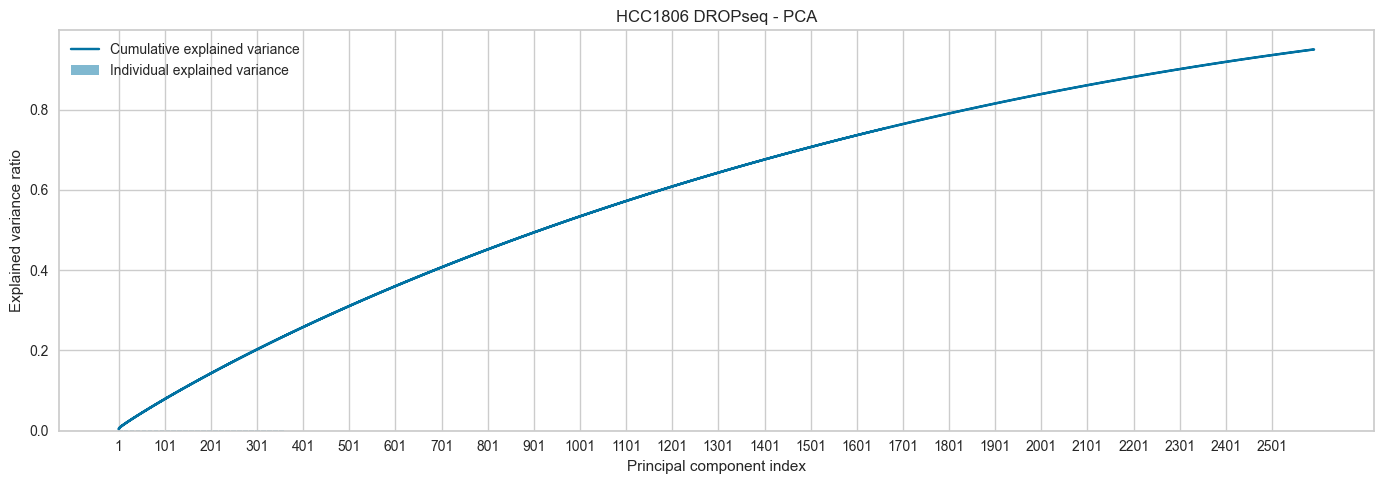

In [9]:
# Plot
exp_var_pca = PCA_HCC_drop.explained_variance_ratio_
v = len(exp_var_pca)
cum_sum_eigenvalues = np.cumsum(exp_var_pca)

plt.figure(figsize=(14, 5))
plt.bar(range(1, v + 1), exp_var_pca, alpha=0.5, align='center', label='Individual explained variance')
plt.step(range(1, v + 1), cum_sum_eigenvalues, where='mid', label='Cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal component index')
plt.xticks(range(1, v + 1, 100))
plt.legend(loc='best')
plt.title('HCC1806 DROPseq - PCA')
plt.tight_layout()
plt.show()

The individual variance bars are invisible at this scale due to how little each individual component contributes to the variance. Therefore, we split the graph into two plots: one for individual explained variance and one for cumulative explained variance.

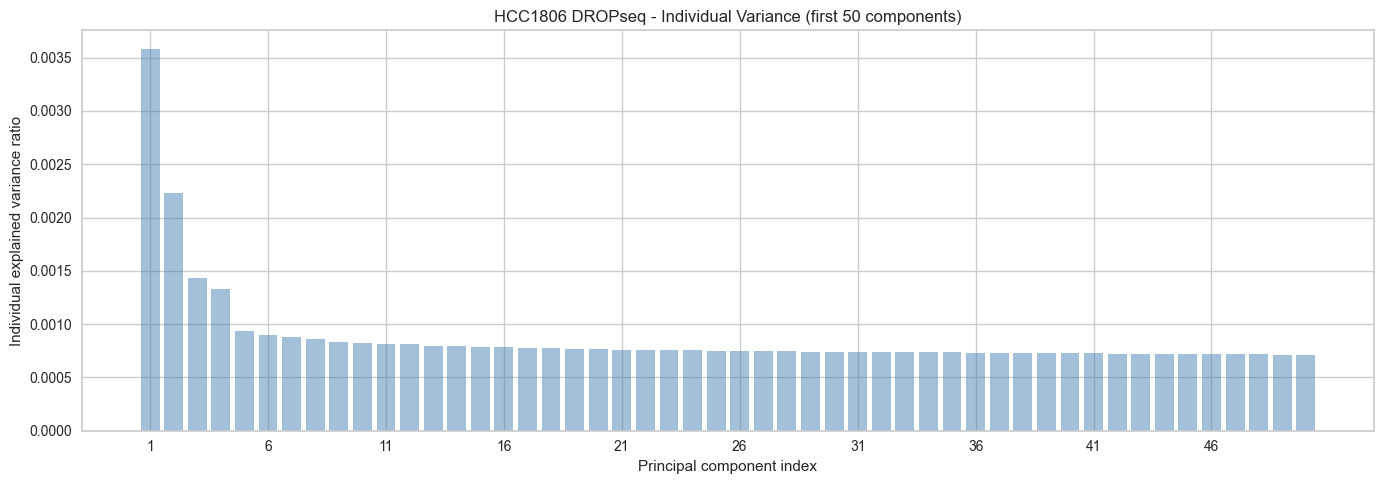

In [10]:
# Individual variance (first 50 components)
plt.figure(figsize=(14, 5))
plt.bar(range(1, 51), exp_var_pca[:50], alpha=0.5, align='center', color='steelblue')
plt.ylabel('Individual explained variance ratio')
plt.xlabel('Principal component index')
plt.title('HCC1806 DROPseq - Individual Variance (first 50 components)')
plt.xticks(range(1, 51, 5))
plt.tight_layout()
plt.show()

Even the most informative component explains less than 0.36% of the variance, 
with a rapid drop after the first few components and almost a flat tail from component 6 onwards

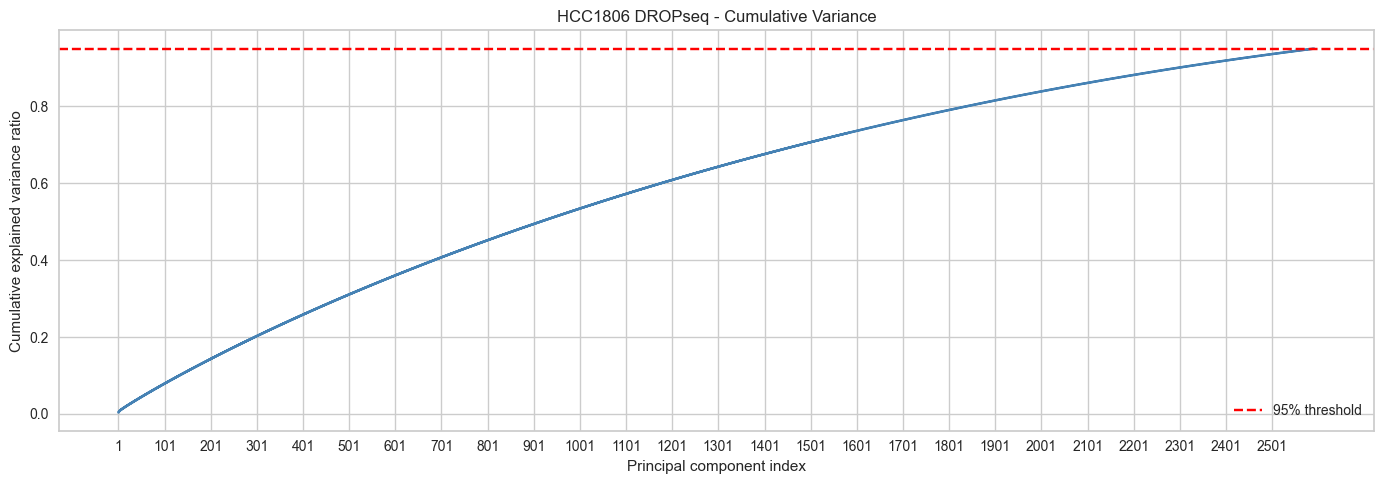

In [11]:
plt.figure(figsize=(14, 5))
plt.step(range(1, v + 1), cum_sum_eigenvalues, where='mid', color='steelblue')
plt.axhline(y=0.95, color='red', linestyle='--', label='95% threshold')
plt.ylabel('Cumulative explained variance ratio')
plt.xlabel('Principal component index')
plt.title('HCC1806 DROPseq - Cumulative Variance')
plt.xticks(range(1, v + 1, 100))
plt.legend()
plt.tight_layout()
plt.show()

The cumulative variance increases gradually across all 2,592 components with no sharp elbow, confirming that variance is spread evenly across a very large number of components with no single dominant axis of variation.

## Visualisation in 2D

In [ ]:
# PCA reducing to 2 components
PCA2_drop = PCA(n_components=2)
principalComponents_drop2 = PCA2_drop.fit_transform(data)

data_drop_pr2 = pd.DataFrame(data=principalComponents_drop2, columns=['PC1', 'PC2'])

print('Explained variation per principal component: {}'.format(PCA2_drop.explained_variance_ratio_))

Explained variation per principal component: [0.00357671 0.00223465]


In [ ]:
# condition labels (0 = Normo, 1 = Hypo)
data_drop_pr2_lab = data_drop_pr2.copy()
data_drop_pr2_lab["Condition"] = labels.map({"Normo": 0, "Hypo": 1}).values

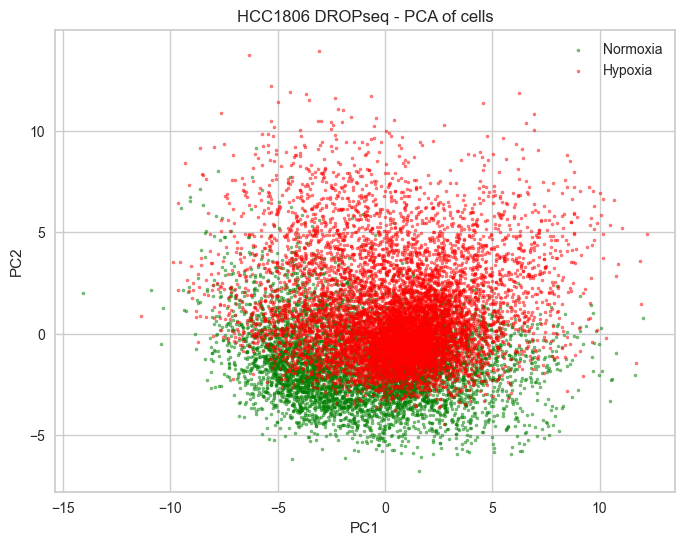

In [ ]:
# 2D plot
plt.figure(figsize=(8, 6))

normo_mask = data_drop_pr2_lab["Condition"] == 0
hypo_mask = data_drop_pr2_lab["Condition"] == 1

plt.scatter(data_drop_pr2_lab.loc[normo_mask, 'PC1'], 
            data_drop_pr2_lab.loc[normo_mask, 'PC2'],
            c='green', label='Normoxia', alpha=0.5, s=5)

plt.scatter(data_drop_pr2_lab.loc[hypo_mask, 'PC1'], 
            data_drop_pr2_lab.loc[hypo_mask, 'PC2'],
            c='red', label='Hypoxia', alpha=0.5, s=5)

plt.title("HCC1806 DROPseq - PCA of cells")
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

The 2D PCA plot shows partial separation between the two conditions, with Hypoxic cells concentrated in the upper region and normoxic cells tending toward the lower half. However, the overlap is extensive and no clear boundary is visible.

## Visualisation in 3D

In [ ]:
# PCA reducing to 3 components
PCA3_drop = PCA(n_components=3)
principalComponents_drop3 = PCA3_drop.fit_transform(data)

data_drop_pr3 = pd.DataFrame(data=principalComponents_drop3, columns=['PC1', 'PC2', 'PC3'])
data_drop_pr3_lab = data_drop_pr3.copy()
data_drop_pr3_lab["Condition"] = labels.map({"Normo": 0, "Hypo": 1}).values

print('Explained variation per principal component: {}'.format(PCA3_drop.explained_variance_ratio_))

Explained variation per principal component: [0.00357671 0.00223465 0.00143228]


Elevation: 20  Azimuth: 45


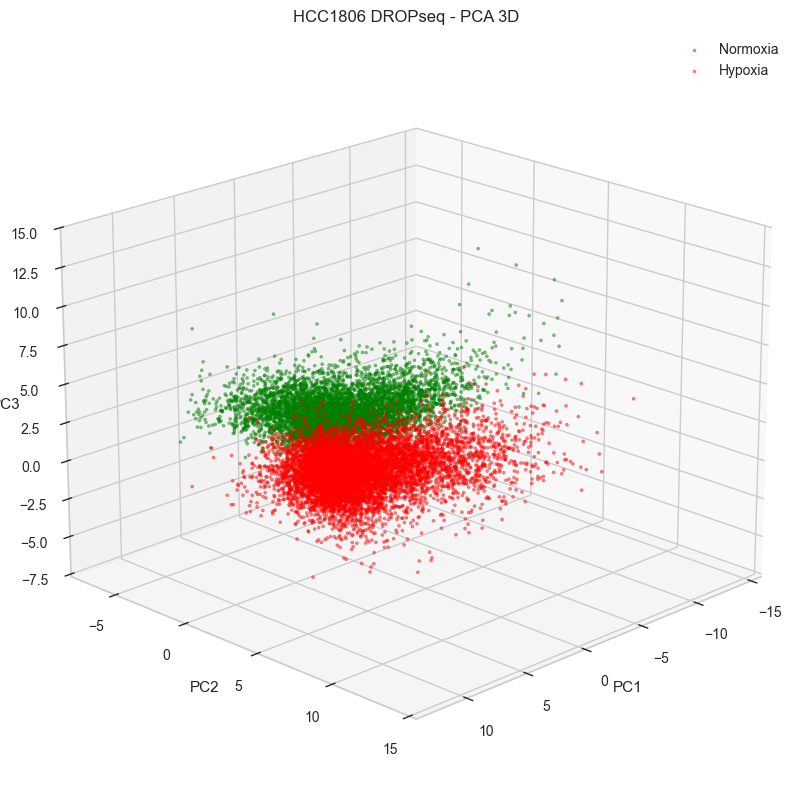

Elevation: 45  Azimuth: 135


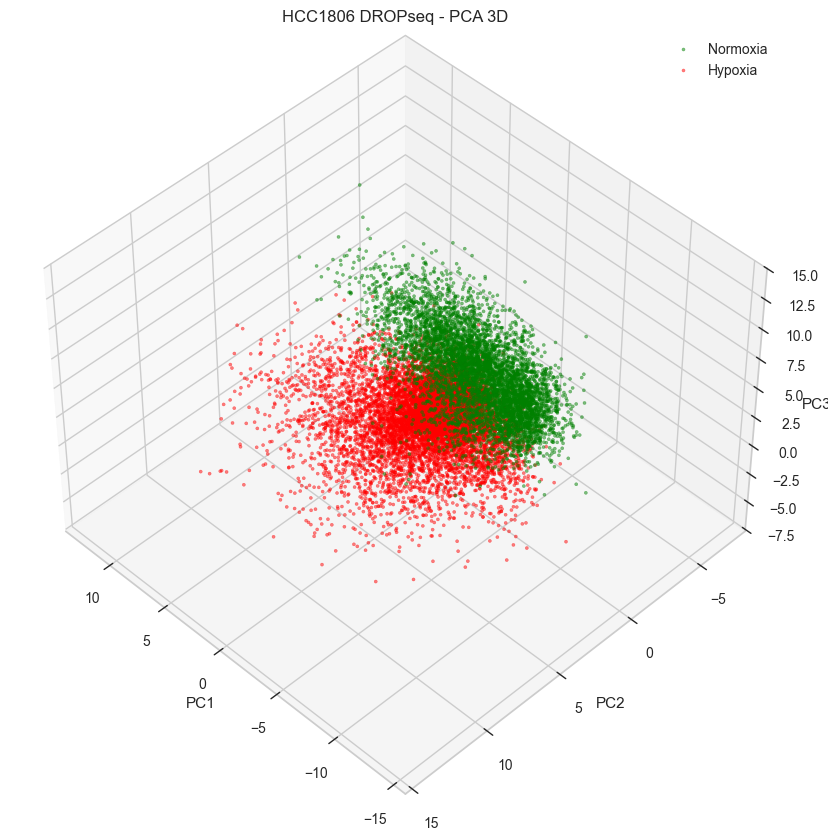

In [16]:
def PCA_3D_drop(EL, AZ):
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(projection='3d')

    normo_mask = data_drop_pr3_lab["Condition"] == 0
    hypo_mask = data_drop_pr3_lab["Condition"] == 1

    ax.scatter(data_drop_pr3_lab.loc[normo_mask, 'PC1'],
               data_drop_pr3_lab.loc[normo_mask, 'PC2'],
               data_drop_pr3_lab.loc[normo_mask, 'PC3'],
               c='green', label='Normoxia', alpha=0.5, s=5)

    ax.scatter(data_drop_pr3_lab.loc[hypo_mask, 'PC1'],
               data_drop_pr3_lab.loc[hypo_mask, 'PC2'],
               data_drop_pr3_lab.loc[hypo_mask, 'PC3'],
               c='red', label='Hypoxia', alpha=0.5, s=5)

    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_zlabel('PC3')
    ax.set_title('HCC1806 DROPseq - PCA 3D')
    ax.legend()
    ax.view_init(elev=EL, azim=AZ)
    print("Elevation:", EL, " Azimuth:", AZ)
    plt.show()

PCA_3D_drop(20, 45)
PCA_3D_drop(45, 135)

Adding a third principal component reveals slightly more separation between the two conditions, with Normoxic cells tending toward higher PC3 values and Hypoxic cells toward lower ones. However, it is important to note that PC1, PC2, and PC3 together still explain a very small fraction of the total variance, so this 3D projection remains a very partial representation of the full dataset structure.

# 4. Clustering


We apply unsupervised clustering to the scaled data to investigate whether cells naturally separate according to their oxygen condition without using the labels. We test two methods, K-Means and Agglomerative Clustering, and evaluate their behaviour both on the full high dimensional data and on the PCA reduced 2D and 3D projections. We conclude with a UMAP visualisation.

## K-Means


### Choosing the number of clusters

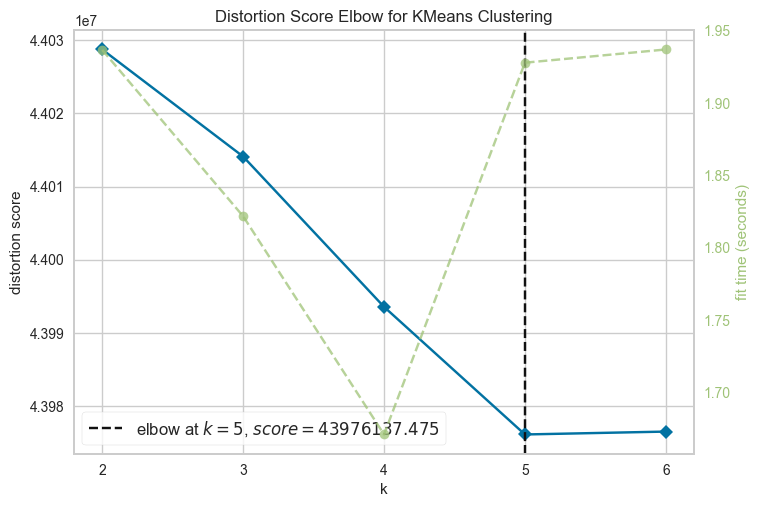

In [17]:
# Elbow method
from yellowbrick.cluster import KElbowVisualizer

fig, ax = plt.subplots()
visualizer = KElbowVisualizer(KMeans(random_state=42), k=(2,7), ax=ax)
visualizer.fit(data)
ax.set_xticks(range(2, 7))
visualizer.show()
plt.show()

The elbow method identifies k=5 as the optimal number of clusters. However, the distortion score decreases almost linearly across all values of k with no pronounced elbow, suggesting that the data does not have a strongly defined cluster structure. Since our biological question concerns a binary condition (Hypoxia vs Normoxia), we proceed with k=2 and k=3 for interpretability.

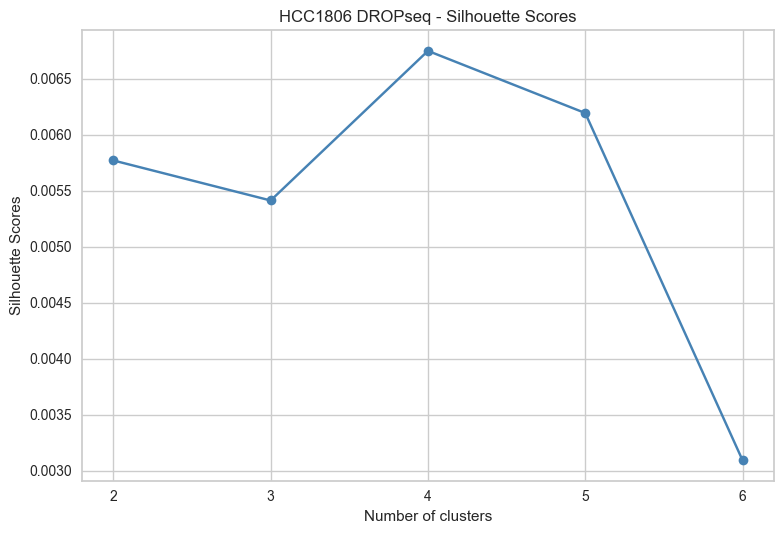

[(2, np.float64(0.006)), (3, np.float64(0.005)), (4, np.float64(0.007)), (5, np.float64(0.006)), (6, np.float64(0.003))]


In [18]:
# Silhouette score
silhouette_scores = []
k_values = range(2, 7)

for k in k_values:
    km = KMeans(n_clusters=k, max_iter=500, tol=1e-04,
                init='k-means++', n_init=20, random_state=42)
    km.fit(data)
    silhouette_scores.append(silhouette_score(data, km.labels_))

fig, ax = plt.subplots()
ax.plot(k_values, silhouette_scores, marker='o', color='steelblue')
ax.set_xlabel('Number of clusters')
ax.set_ylabel('Silhouette Scores')
ax.set_title('HCC1806 DROPseq - Silhouette Scores')
plt.xticks(k_values)
plt.tight_layout()
plt.show()

print(list(zip(k_values, [round(s, 3) for s in silhouette_scores])))

In [20]:
# Check cluster sizes for each K
for k in range(2, 7):
    km = KMeans(n_clusters=k, max_iter=500, tol=1e-04,
                init='k-means++', n_init=20, random_state=42)
    km.fit(data)
    counts = pd.Series(km.labels_).value_counts().sort_index()
    score = silhouette_score(data, km.labels_)
    print(f"K={k} | Score: {score:.3f} | Cluster sizes: {counts.values}")

K=2 | Score: 0.006 | Cluster sizes: [5448 9234]
K=3 | Score: 0.005 | Cluster sizes: [5409 9205   68]
K=4 | Score: 0.007 | Cluster sizes: [   3 8936   18 5725]
K=5 | Score: 0.006 | Cluster sizes: [  11   14   82 5678 8897]
K=6 | Score: 0.003 | Cluster sizes: [3183 7223    1   27    2 4246]


The silhouette scores computed on the full dataset are extremely low across all values of k (ranging from 0.003 to 0.007), indicating that the clusters are not well separated. Comparing cluster sizes, k=2 produces the most balanced split (5448 vs 9234 cells). At k=4 and k=5, some clusters contain as few as 3 or 11 cells while others hold thousands, indicating degenerate solutions. We therefore proceed with k=2 as our primary choice.

### K=2 Clustering

In [ ]:
# Running K-Means with K=2
kmeans_2 = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_2.fit(data)

print("Cluster counts:")
print(pd.Series(kmeans_2.labels_).value_counts())

Cluster counts:
1    9234
0    5448
Name: count, dtype: int64


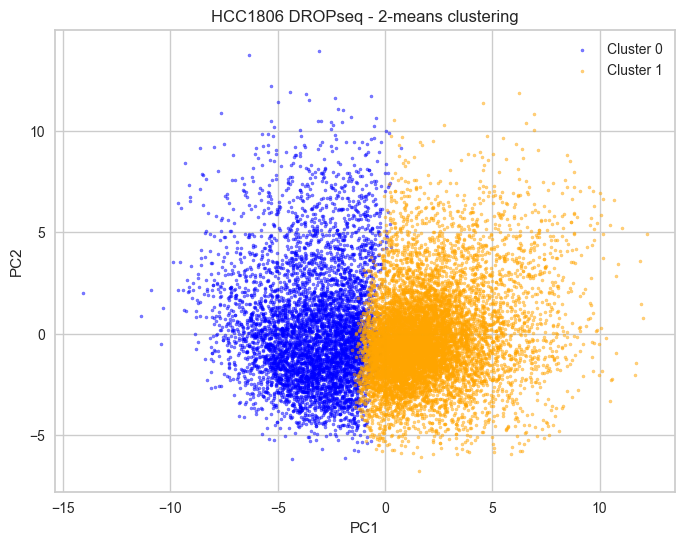

In [ ]:
# 2D  plot
plt.figure(figsize=(8, 6))

cluster0_mask = kmeans_2.labels_ == 0
cluster1_mask = kmeans_2.labels_ == 1

plt.scatter(data_drop_pr2_lab.loc[cluster0_mask, 'PC1'],
            data_drop_pr2_lab.loc[cluster0_mask, 'PC2'],
            c='blue', label='Cluster 0', alpha=0.5, s=5)

plt.scatter(data_drop_pr2_lab.loc[cluster1_mask, 'PC1'],
            data_drop_pr2_lab.loc[cluster1_mask, 'PC2'],
            c='orange', label='Cluster 1', alpha=0.5, s=5)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('HCC1806 DROPseq - 2-means clustering')
plt.legend()
plt.show()

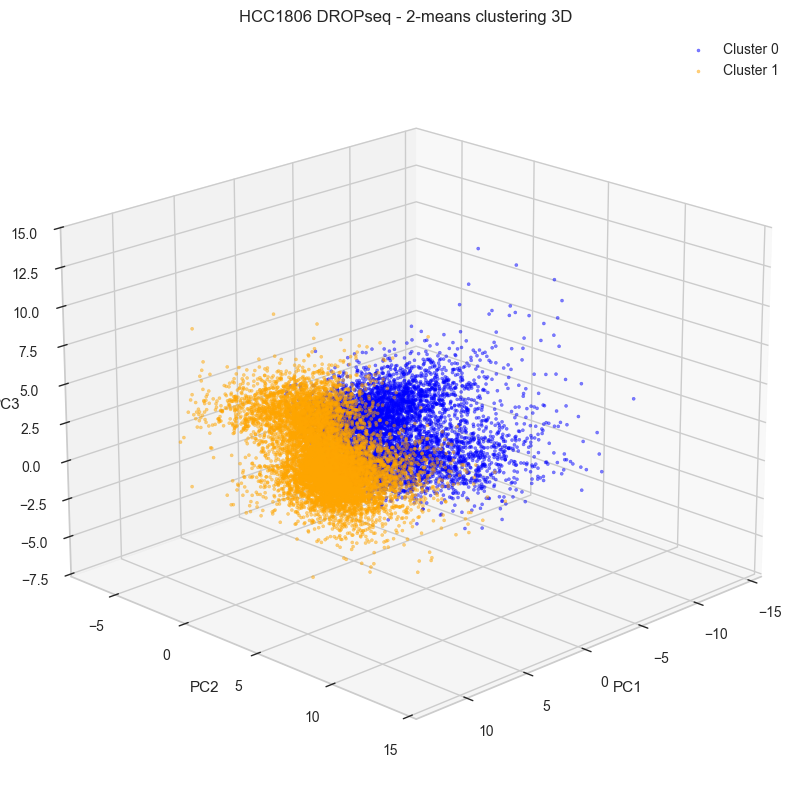

In [ ]:
# 3D plot
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

cluster0_mask = kmeans_2.labels_ == 0
cluster1_mask = kmeans_2.labels_ == 1

ax.scatter(data_drop_pr3_lab.loc[cluster0_mask, 'PC1'],
           data_drop_pr3_lab.loc[cluster0_mask, 'PC2'],
           data_drop_pr3_lab.loc[cluster0_mask, 'PC3'],
           c='blue', label='Cluster 0', alpha=0.5, s=5)

ax.scatter(data_drop_pr3_lab.loc[cluster1_mask, 'PC1'],
           data_drop_pr3_lab.loc[cluster1_mask, 'PC2'],
           data_drop_pr3_lab.loc[cluster1_mask, 'PC3'],
           c='orange', label='Cluster 1', alpha=0.5, s=5)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('HCC1806 DROPseq - 2-means clustering 3D')
ax.legend()
ax.view_init(elev=20, azim=45)
plt.show()

K-Means with k=2 produces two clusters of 5,448 and 9,234 cells. In both the 2D and 3D PCA projections, the clusters show some separation primarily along the PC1 axis, with Cluster 0 occupying the negative region and Cluster 1 the positive region.

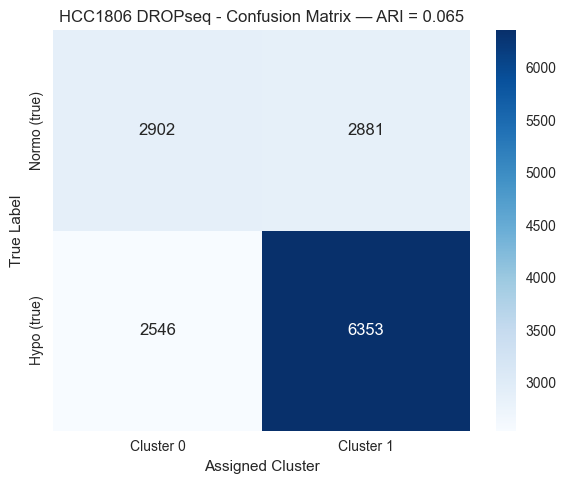

Adjusted Rand Index: 0.065


In [ ]:
# confusion matrix
og_labels = data_drop_pr2_lab["Condition"].values
true_numeric = (pd.Series(data_drop_pr2_lab["Condition"].values) == 1).astype(int).values
ari = adjusted_rand_score(true_numeric, kmeans_2.labels_)
cm = confusion_matrix(true_numeric, kmeans_2.labels_)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cluster 0', 'Cluster 1'],
            yticklabels=['Normo (true)', 'Hypo (true)'])
plt.title(f'HCC1806 DROPseq - Confusion Matrix — ARI = {ari:.3f}')
plt.ylabel('True Label')
plt.xlabel('Assigned Cluster')
plt.tight_layout()
plt.show()

print(f"Adjusted Rand Index: {ari:.3f}")

The confusion matrix shows that cluster 1 captures the majority of hypoxic cells (6353 out of 8899), while normoxic cells are split almost equally between the two clusters (2902 vs 2881). The ARI of 0.065 confirms indicates a clustering that is close to random with respect to the true labels.

In [ ]:
# clustering accuracy
def clustering_accuracy(clust_labels, og_labels):
    clust_labels = np.array(clust_labels)
    og_labels = np.array(og_labels)
    mapped = np.zeros_like(clust_labels)
    for cluster in np.unique(clust_labels):
        mask = clust_labels == cluster
        mapped[mask] = np.bincount(og_labels[mask]).argmax()
    acc = np.mean(mapped == og_labels) * 100
    print(f"Clustering accuracy: {acc:.2f} %")

clustering_accuracy(kmeans_2.labels_, og_labels)

Clustering accuracy: 63.04 %


The clustering accuracy of 63.04% indicates that K-Means only partially recovers the true biological labels. This is likely due to the high dimensionality of the dataset, suggesting that running clustering on PCA reduced data may yield better results.

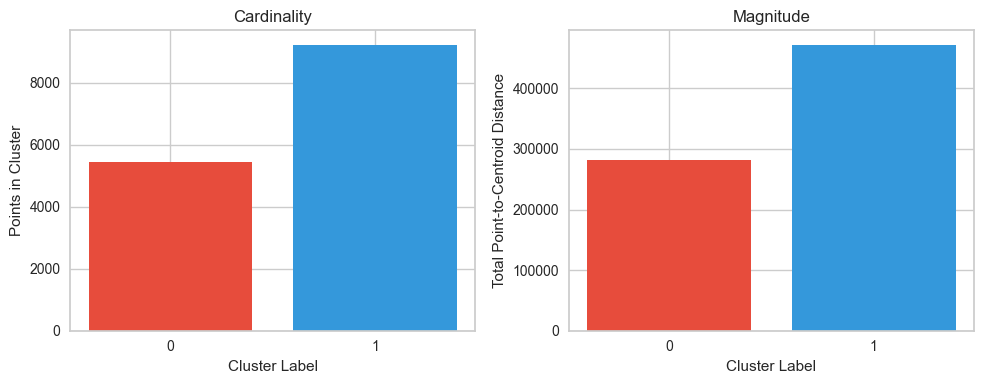

In [26]:
def diagnoses(kmeans_model, data):
    n_clusters = kmeans_model.n_clusters
    labels = kmeans_model.labels_
    centers = kmeans_model.cluster_centers_

    cardinality = [np.sum(labels == i) for i in range(n_clusters)]

    magnitude = []
    for i in range(n_clusters):
        cluster_points = data[labels == i]
        distances = np.linalg.norm(cluster_points - centers[i], axis=1)
        magnitude.append(np.sum(distances))

    bar_colors = ['#e74c3c', '#3498db', '#2ecc71'][:n_clusters]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].bar(range(n_clusters), cardinality, color=bar_colors)
    axes[0].set_xlabel('Cluster Label')
    axes[0].set_ylabel('Points in Cluster')
    axes[0].set_title('Cardinality')
    axes[0].set_xticks(range(n_clusters))

    axes[1].bar(range(n_clusters), magnitude, color=bar_colors)
    axes[1].set_xlabel('Cluster Label')
    axes[1].set_ylabel('Total Point-to-Centroid Distance')
    axes[1].set_title('Magnitude')
    axes[1].set_xticks(range(n_clusters))

    plt.tight_layout()
    plt.show()

diagnoses(kmeans_2, data.values)

The cardinality and magnitude plots show that Cluster 1 is larger and more spread out than Cluster 0, which might be partially influenced by the class imbalance identified in the EDA (61% hypoxia, 39% normoxia), though the overall cluster structure appears to be primarily driven by the data geometry rather than condition.

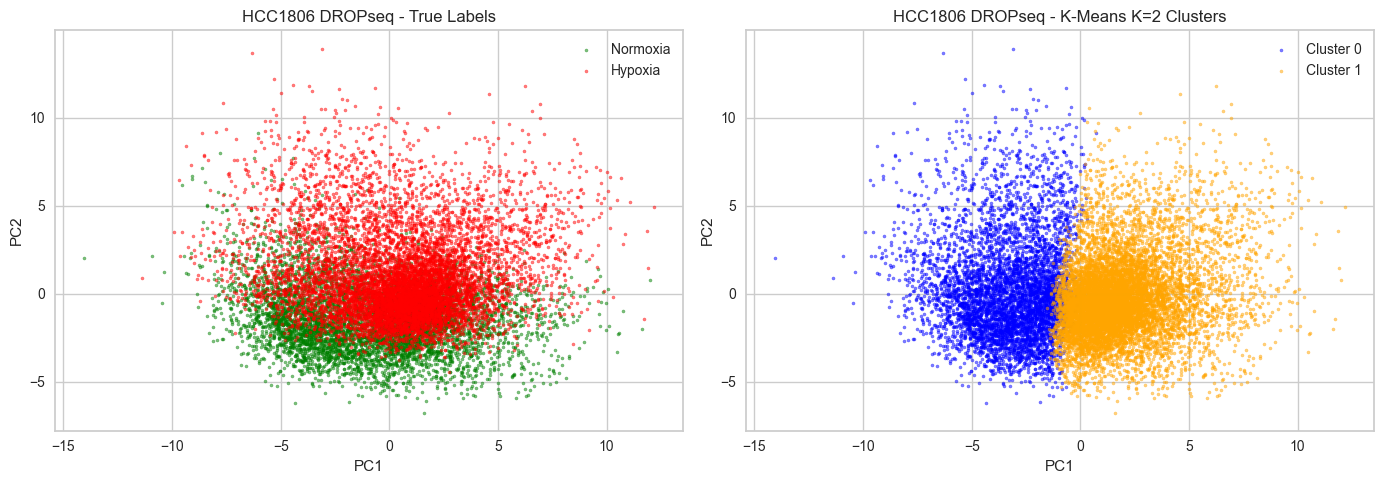

In [ ]:
# true labels vs K-Means K=2 plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

normo_mask = data_drop_pr2_lab["Condition"] == 0
hypo_mask = data_drop_pr2_lab["Condition"] == 1

axes[0].scatter(data_drop_pr2_lab.loc[normo_mask, 'PC1'],
                data_drop_pr2_lab.loc[normo_mask, 'PC2'],
                c='green', label='Normoxia', alpha=0.5, s=5)
axes[0].scatter(data_drop_pr2_lab.loc[hypo_mask, 'PC1'],
                data_drop_pr2_lab.loc[hypo_mask, 'PC2'],
                c='red', label='Hypoxia', alpha=0.5, s=5)
axes[0].set_title('HCC1806 DROPseq - True Labels')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()

cluster0_mask = kmeans_2.labels_ == 0
cluster1_mask = kmeans_2.labels_ == 1

axes[1].scatter(data_drop_pr2_lab.loc[cluster0_mask, 'PC1'],
                data_drop_pr2_lab.loc[cluster0_mask, 'PC2'],
                c='blue', label='Cluster 0', alpha=0.5, s=5)
axes[1].scatter(data_drop_pr2_lab.loc[cluster1_mask, 'PC1'],
                data_drop_pr2_lab.loc[cluster1_mask, 'PC2'],
                c='orange', label='Cluster 1', alpha=0.5, s=5)
axes[1].set_title('HCC1806 DROPseq - K-Means K=2 Clusters')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend()

plt.tight_layout()
plt.show()

The side by side comparison between true labels and clustering labels shows that K-Means splits cells along the PC1 axis, which does not align with the true condition separation. While the true labels show a diagonal pattern, the clusters divide the space vertically. This suggests that K-Means did not recover the hypoxia normoxia structure from the data.

### K=3 Clustering

In [ ]:
# run K-Means with K=3
kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_3.fit(data)

print("Cluster counts:")
print(pd.Series(kmeans_3.labels_).value_counts())

Cluster counts:
1    9205
0    5409
2      68
Name: count, dtype: int64


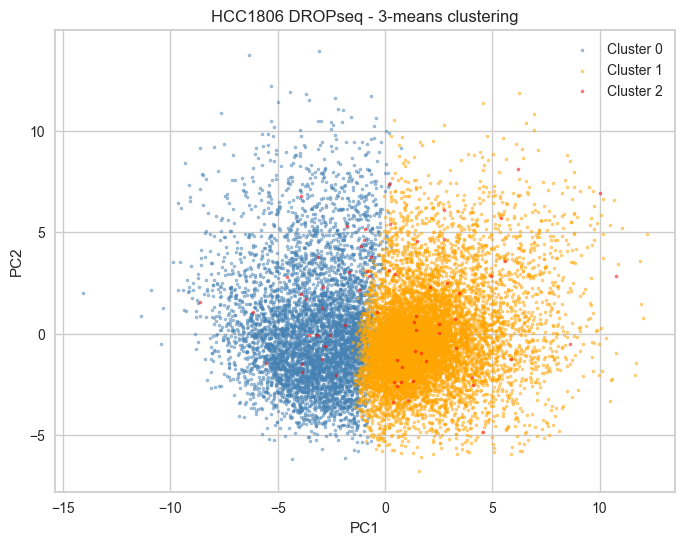

In [ ]:
# 2D plot
plt.figure(figsize=(8, 6))

cluster0_mask = kmeans_3.labels_ == 0
cluster1_mask = kmeans_3.labels_ == 1
cluster2_mask = kmeans_3.labels_ == 2

plt.scatter(data_drop_pr2_lab.loc[cluster0_mask, 'PC1'],
            data_drop_pr2_lab.loc[cluster0_mask, 'PC2'],
            c='steelblue', label='Cluster 0', alpha=0.5, s=5)

plt.scatter(data_drop_pr2_lab.loc[cluster1_mask, 'PC1'],
            data_drop_pr2_lab.loc[cluster1_mask, 'PC2'],
            c='orange', label='Cluster 1', alpha=0.5, s=5)

plt.scatter(data_drop_pr2_lab.loc[cluster2_mask, 'PC1'],
            data_drop_pr2_lab.loc[cluster2_mask, 'PC2'],
            c='red', label='Cluster 2', alpha=0.5, s=5)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('HCC1806 DROPseq - 3-means clustering')
plt.legend()
plt.show()

In [30]:
#clustering acuracy
clustering_accuracy(kmeans_3.labels_, og_labels)

Clustering accuracy: 63.02 %


K-Means with k=3 produces a degenerate solution: two large clusters of 9205 and 5409 cells and one small cluster of only 68 cells. The 2D projection confirms that the partition again follows the PC1 axis rather than the biological condition structure, with cluster 2 reduced to a few scattered points. The clustering accuracy of 63.02% is essentially the same as k=2, confirming that adding a third cluster brings no meaningful improvement. This supports k=2 as the only meaningful choice for this dataset.

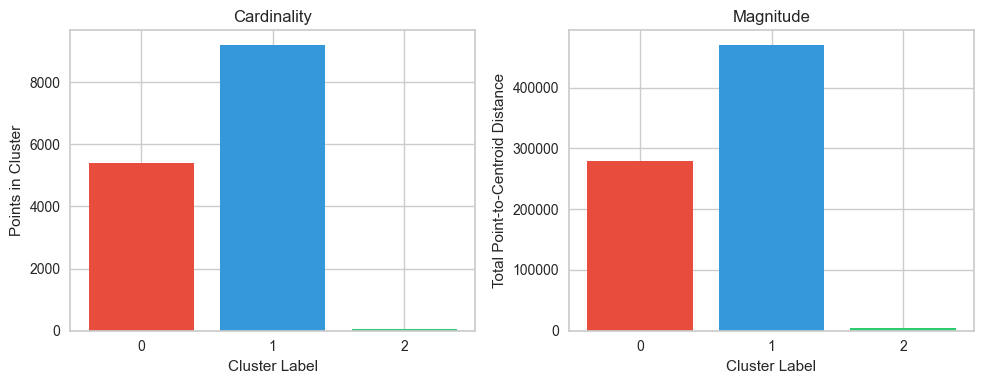

In [31]:
diagnoses(kmeans_3, data.values)

The cardinality and magnitude plots confirm the imbalanced nature of the k=3 solution. Cluster 2 is negligible in both size and total spread, while Clusters 0 and 1 are nearly identical to the k=2 partition

## Agglomerative Clustering

In [ ]:
# Run agglomerative clustering
agglomerative = AgglomerativeClustering(n_clusters=2, linkage='ward', compute_distances=True)
agglomerative.fit(data)

print("Cluster counts:")
print(pd.Series(agglomerative.labels_).value_counts())

Cluster counts:
0    14681
1        1
Name: count, dtype: int64


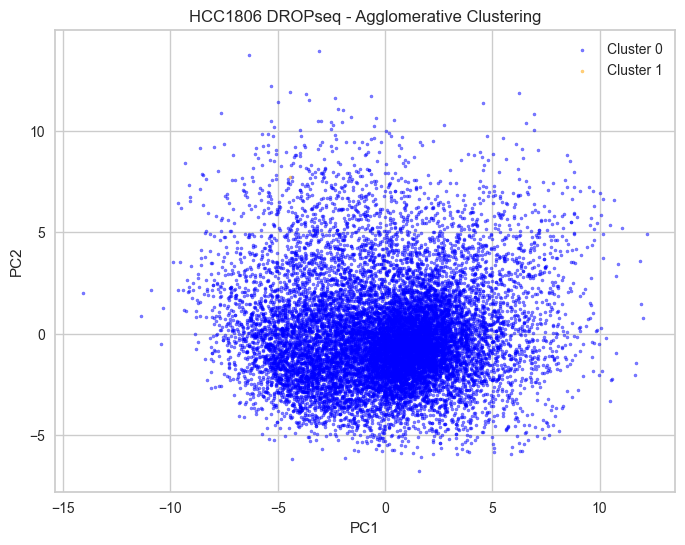

In [ ]:
#2D plot
plt.figure(figsize=(8, 6))

cluster0_mask = agglomerative.labels_ == 0
cluster1_mask = agglomerative.labels_ == 1

plt.scatter(data_drop_pr2_lab.loc[cluster0_mask, 'PC1'],
            data_drop_pr2_lab.loc[cluster0_mask, 'PC2'],
            c='blue', label='Cluster 0', alpha=0.5, s=5)

plt.scatter(data_drop_pr2_lab.loc[cluster1_mask, 'PC1'],
            data_drop_pr2_lab.loc[cluster1_mask, 'PC2'],
            c='orange', label='Cluster 1', alpha=0.5, s=5)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('HCC1806 DROPseq - Agglomerative Clustering')
plt.legend()
plt.show()

Agglomerative clustering on the full DROPseq dataset completely fails, assigning 14681 cells to Cluster 0 and only 1 cell to Cluster 1. The 2D projection confirms this, as the entire dataset appears as a single cluster. It is a known limitation that agglomerative clustering does not scale well to large high dimensional datasets. We therefore try to run it on the PCA reduced components instead.

### Clustering of principal components

**agglomerative clustering on 2D PCA components**

In [34]:
# Agglomerative clustering on 2D PCA components
agg_PC2 = AgglomerativeClustering(n_clusters=2, linkage='ward')
agg_PC2.fit(data_drop_pr2)

print("Cluster counts:")
print(pd.Series(agg_PC2.labels_).value_counts())

Cluster counts:
0    7893
1    6789
Name: count, dtype: int64


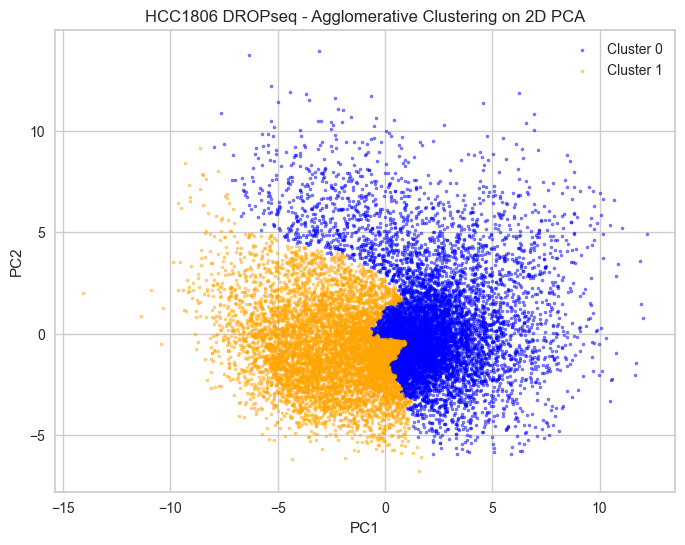

In [35]:
#Plot
plt.figure(figsize=(8, 6))

cluster0_mask = agg_PC2.labels_ == 0
cluster1_mask = agg_PC2.labels_ == 1

plt.scatter(data_drop_pr2_lab.loc[cluster0_mask, 'PC1'],
            data_drop_pr2_lab.loc[cluster0_mask, 'PC2'],
            c='blue', label='Cluster 0', alpha=0.5, s=5)

plt.scatter(data_drop_pr2_lab.loc[cluster1_mask, 'PC1'],
            data_drop_pr2_lab.loc[cluster1_mask, 'PC2'],
            c='orange', label='Cluster 1', alpha=0.5, s=5)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('HCC1806 DROPseq - Agglomerative Clustering on 2D PCA')
plt.legend()
plt.show()

In [36]:
#Clusteing acuracy
clustering_accuracy(agg_PC2.labels_, og_labels)

Clustering accuracy: 64.31 %


Agglomerative clustering on the 2D PCA components produces a much more balanced split of 7893 and 6789 cells, which is a clear improvement compared to the collapsed solution on the full data. Unlike K-means, the partition boundary is non linear. However, given that PC1 and PC2 together explain less than 1% of the total variance, this projection is too limited to draw strong conclusions. The clustering accuracy of 64.31% is a marginal improvement over K-Means but remains limited overall.

**agglomerative clustering on 3D PCA components**

In [37]:
# Agglomerative clustering on 3D PCA components
agg_PC3 = AgglomerativeClustering(n_clusters=2, linkage='ward')
agg_PC3.fit(data_drop_pr3)

print("Cluster counts:")
print(pd.Series(agg_PC3.labels_).value_counts())

Cluster counts:
0    10521
1     4161
Name: count, dtype: int64


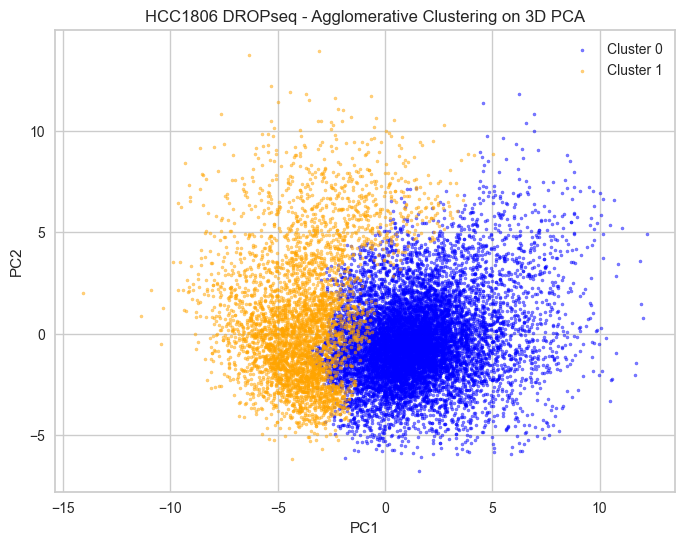

In [38]:
#Plot
plt.figure(figsize=(8, 6))

cluster0_mask = agg_PC3.labels_ == 0
cluster1_mask = agg_PC3.labels_ == 1

plt.scatter(data_drop_pr3_lab.loc[cluster0_mask, 'PC1'],
            data_drop_pr3_lab.loc[cluster0_mask, 'PC2'],
            c='blue', label='Cluster 0', alpha=0.5, s=5)

plt.scatter(data_drop_pr3_lab.loc[cluster1_mask, 'PC1'],
            data_drop_pr3_lab.loc[cluster1_mask, 'PC2'],
            c='orange', label='Cluster 1', alpha=0.5, s=5)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('HCC1806 DROPseq - Agglomerative Clustering on 3D PCA')
plt.legend()
plt.show()

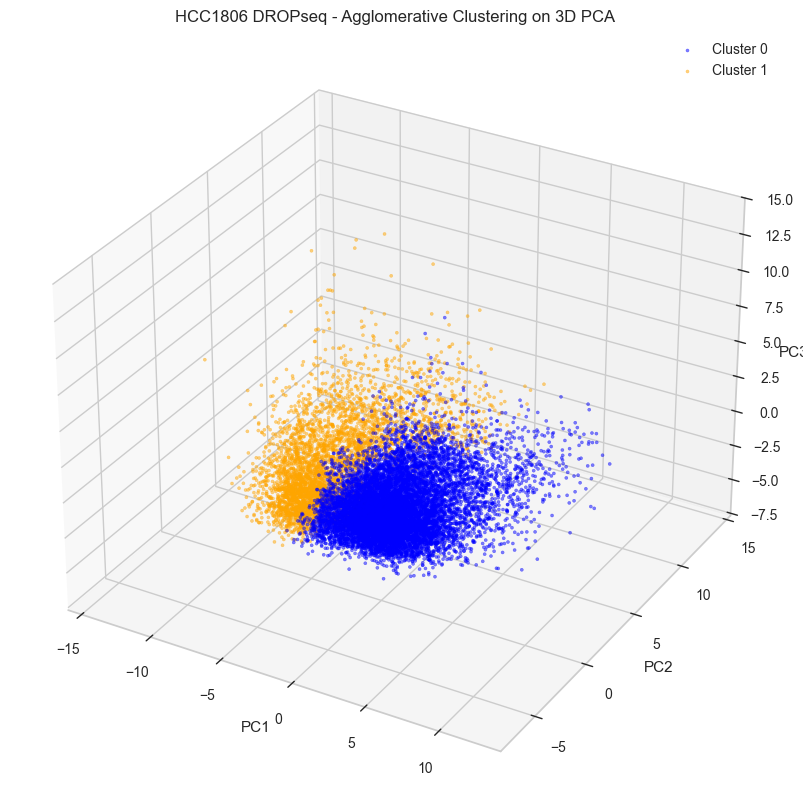

In [39]:
# 3D scatter plot
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

cluster0_mask = agg_PC3.labels_ == 0
cluster1_mask = agg_PC3.labels_ == 1

ax.scatter(data_drop_pr3_lab.loc[cluster0_mask, 'PC1'],
           data_drop_pr3_lab.loc[cluster0_mask, 'PC2'],
           data_drop_pr3_lab.loc[cluster0_mask, 'PC3'],
           c='blue', label='Cluster 0', alpha=0.5, s=5)

ax.scatter(data_drop_pr3_lab.loc[cluster1_mask, 'PC1'],
           data_drop_pr3_lab.loc[cluster1_mask, 'PC2'],
           data_drop_pr3_lab.loc[cluster1_mask, 'PC3'],
           c='orange', label='Cluster 1', alpha=0.5, s=5)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('HCC1806 DROPseq - Agglomerative Clustering on 3D PCA')
ax.legend()
plt.show()

In [40]:
#Clustering Accuracy
clustering_accuracy(agg_PC3.labels_, og_labels)

Clustering accuracy: 65.55 %


Both results are a clear improvement over the full data collapse. The 3D PCA clustering (65.55%) marginally outperforms the 2D case (64.31%), suggesting that the third component adds a small amount of useful structure. However, the 2D split (7,893 vs 6,789) is more balanced than the 3D split (10,521 vs 4,161), meaning the accuracy gain comes at the cost of cluster balance. Overall, this confirms that dimensionality reduction is necessary for agglomerative clustering to produce meaningful results on this dataset.

## UMAP

UMAP is a nonlinear dimensionality reduction technique that allows us to visualise high dimensional data in 2D. Unlike PCA, UMAP can capture nonlinear relationships between cells, making it useful when linear methods struggle to reveal clear structure. We use UMAP purely as a visualisation tool, projecting the true labels and the K-Means (k=2) cluster assignments onto the UMAP embedding. We use K-means rather than agglomerative clustering here because the agglomerative clusters were derived from PCA reduced components, and projecting them onto a UMAP embedding would combine two different dimensionality reductions, which would make result interpretation difficult.

In [ ]:
# Run UMAP
#note that data is already scaled (Standardscaler applied at preprocessing step)
import umap

reducer = umap.UMAP(n_components=2, random_state=42)
embedding = reducer.fit_transform(data)

#store result in a DataFrame
data_umap = pd.DataFrame(embedding, columns=['UMAP1', 'UMAP2'])

print("UMAP embedding shape:", data_umap.shape)
data_umap.head()

/Users/Giuly/Library/Python/3.9/lib/python/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP embedding shape: (14682, 2)


,UMAP1,UMAP2
0,1.496804,3.232221
1,1.033556,3.062002
2,-1.605644,1.243340
3,1.801689,2.929536
4,-1.055002,0.691385


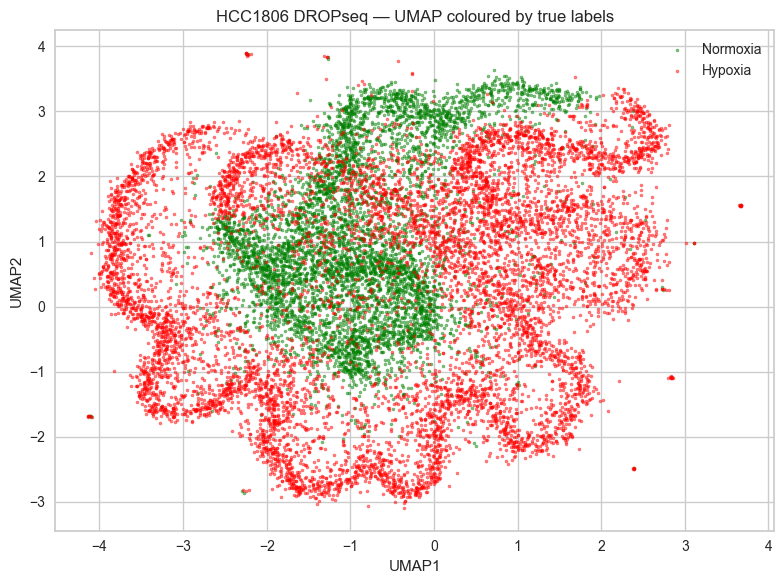

In [52]:
# Plot UMAP coloured by true labels
plt.figure(figsize=(8, 6))

normo_mask = data_drop_pr2_lab['Condition'] == 0
hypo_mask = data_drop_pr2_lab['Condition'] == 1

plt.scatter(data_umap.loc[normo_mask, 'UMAP1'], data_umap.loc[normo_mask, 'UMAP2'],
            c='green', label='Normoxia', alpha=0.5, s=5)
plt.scatter(data_umap.loc[hypo_mask, 'UMAP1'], data_umap.loc[hypo_mask, 'UMAP2'],
            c='red', label='Hypoxia', alpha=0.5, s=5)

plt.title('HCC1806 DROPseq — UMAP coloured by true labels')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.legend()
plt.tight_layout()
plt.show()

The UMAP embedding shows that normoxic cells are concentrated in the central region, while hypoxic cells form a surrounding ring structure. Despite this spatial organisation, the overlap between the two conditions remains substantial and no clean boundary is visible. Further investigation, on alternative nonlinear methods could help clarify whether this structure reflects real biological signal or is an artefact introduced by the embedding process

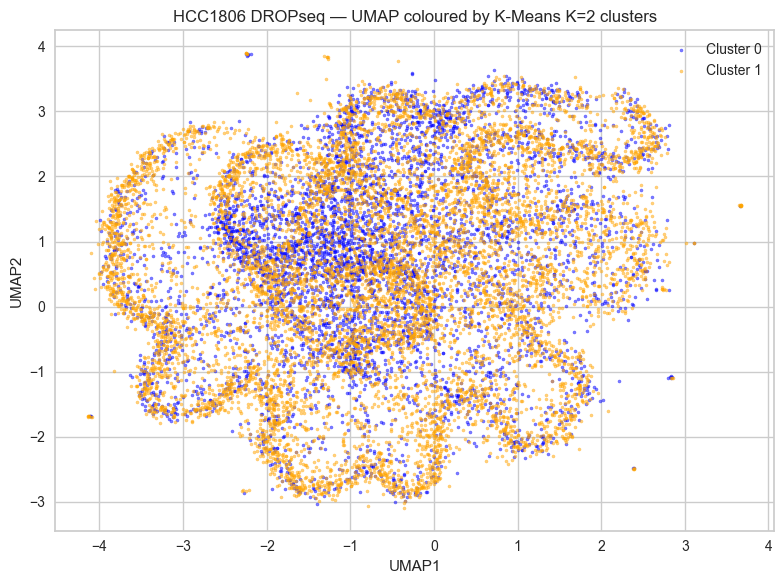

In [ ]:
#plot K-Means K=2 labels on UMAP data
plt.figure(figsize=(8, 6))

for cluster, color, label in [(0, 'blue', 'Cluster 0'), (1, 'orange', 'Cluster 1')]:
    mask = kmeans_2.labels_ == cluster
    plt.scatter(data_umap.loc[mask, 'UMAP1'], data_umap.loc[mask, 'UMAP2'],
                c=color, label=label, alpha=0.5, s=5)

plt.title('HCC1806 DROPseq — UMAP coloured by K-Means K=2 clusters')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.legend()
plt.tight_layout()
plt.show()

Projecting the k-means clusters onto the UMAP embedding shows no meaningful separation, with the two clusters scattered throughout the entire space. Combined with the uncertainty about the UMAP structure itself, we conclude that UMAP was inconclusive for this dataset.

# Conclusion

This analysis applied PCA, K-Means, Agglomerative Clustering, and UMAP to the HCC1806 DROPseq dataset to investigate whether unsupervised methods could recover the biological separation between hypoxic and normoxic cells.

PCA required 2592 components to explain 95% of the variance, reflecting the high complexity of the DROPseq data where information is spread quite evenly across nearly all genes. Both the 2D and 3D projections showed only partial separation between the two conditions, with no sharp boundary visible, and each component explaining less than 0.36% of the variance individually.

Clustering was not highly successful. K-Means on the full dataset achieved 63.04% accuracy, separating cells along the PC1 axis rather than recovering the biological condition. Agglomerative clustering on the full data completely failed, collapsing 14681 cells into a single cluster, which is explained by the known scalability limitations of this method on large high dimensional datasets. Running agglomerative clustering on PCA reduced components mildly improved results (64.31% on 2D, 65.55% on 3D). UMAP revealed an interesting structure with normoxic cells concentrated in the centre and hypoxic cells surrounding them, but projecting K-means clusters onto the embedding showed no meaningful separation, making UMAP inconclusive for this dataset.

Overall, unsupervised methods were unable to reliably separate the two conditions. The main challenge is the high dimensionality of DROPseq data combined with the absence of label information. This suggests that supervised learning should be run on the provided filtered normalised dataset, as no clustering or dimensionality reduction technique was sufficiently effective.